In [31]:
import netCDF4 as nc
import matplotlib.pyplot as plt
import numpy as np
import bnf_functions as bnf
import importlib

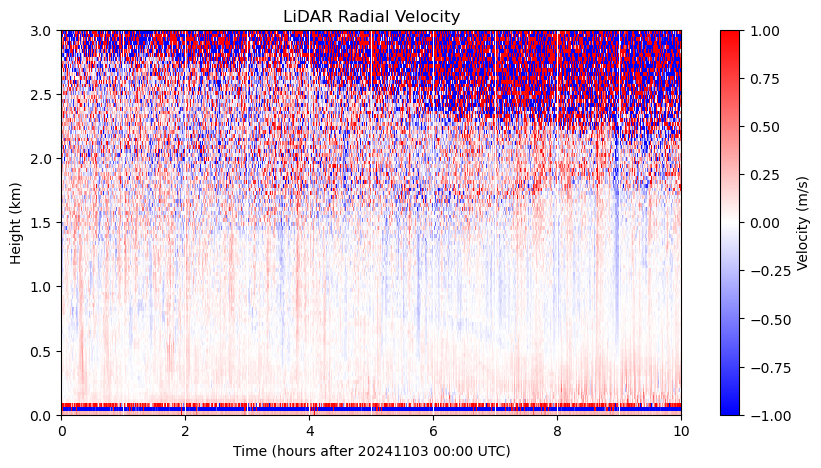

In [71]:
importlib.reload(bnf)
input_path = '/thumper/users/ivan.ariashernandez/data/BNF/251419'
day = 20241103
fig = bnf.plot_velocity_day(input_path, day)

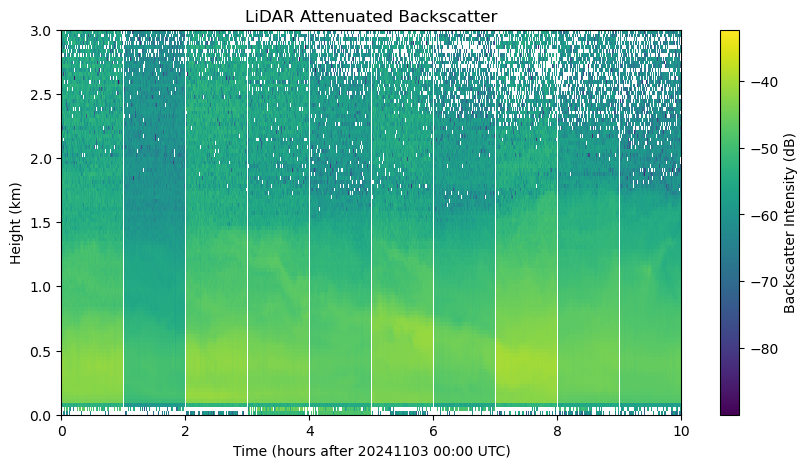

In [72]:
importlib.reload(bnf)
input_path = '/thumper/users/ivan.ariashernandez/data/BNF/251419'
day = 20241103
fig = bnf.plot_backscatter_day(input_path, day)

<Figure size 1200x1000 with 0 Axes>

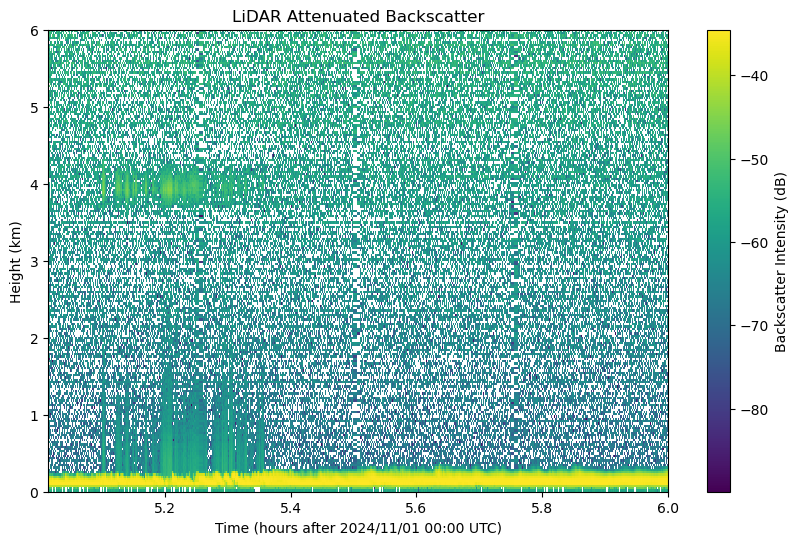

In [47]:
importlib.reload(bnf)
file = '/thumper/users/ivan.ariashernandez/data/BNF/251419/bnfdlfptM1.b1.20241101.050054.cdf'
fig = bnf.plot_backscatter(file)

<Figure size 1200x1000 with 0 Axes>

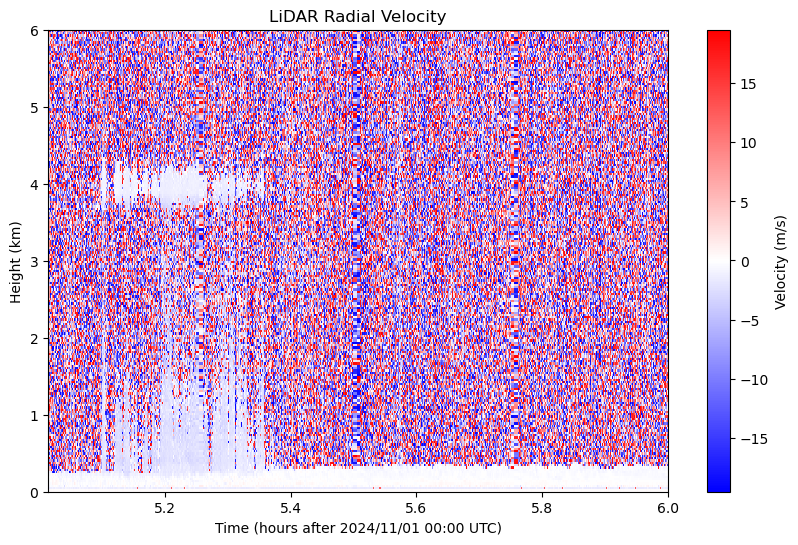

In [39]:
importlib.reload(bnf)
file = '/thumper/users/ivan.ariashernandez/data/BNF/251419/bnfdlfptM1.b1.20241101.050054.cdf'
fig = bnf.plot_velocity(file)

In [10]:
file = '/thumper/users/ivan.ariashernandez/data/BNF/251419/bnfdlfptM1.b1.20241101.050054.cdf'
dataset = nc.Dataset(file, 'r')

# Check available variables in the dataset
print(dataset.variables.keys())
a = 1

dict_keys(['base_time', 'time_offset', 'time', 'range', 'azimuth', 'elevation', 'radial_velocity', 'qc_radial_velocity', 'intensity', 'attenuated_backscatter', 'pitch', 'roll', 'lat', 'lon', 'alt'])


In [5]:
time = dataset.variables['time'][:]
range = dataset.variables['range'][:]
backscatter = dataset.variables['attenuated_backscatter'][:]

# Close the dataset after loading variables
dataset.close()

In [24]:
backscatter_dB = 10*np.log10(backscatter)
backscatter_dB = np.ma.masked_less(backscatter_dB, -90)
a = 1

/tmp/ipykernel_3721173/1311472846.py:1: RuntimeWarning: invalid value encountered in log10
  backscatter_dB = 10*np.log10(backscatter)


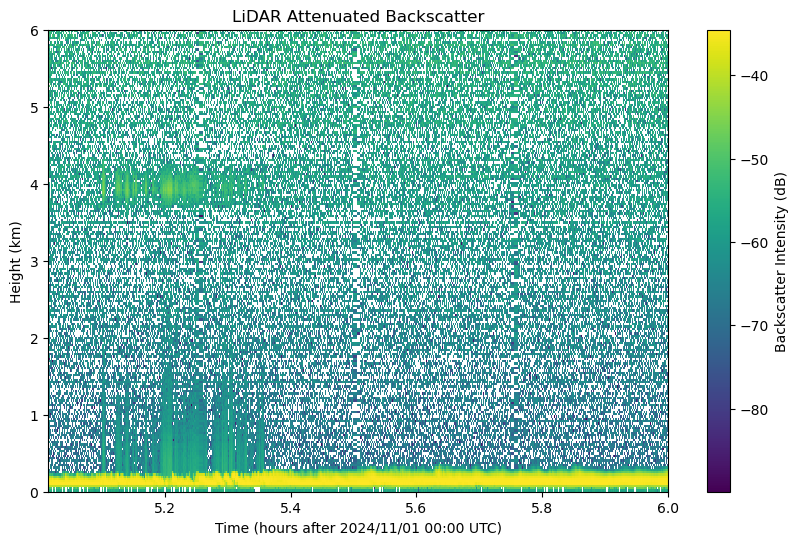

In [29]:
# Convert time if necessary (depends on the units in the CDF file)
time_hours = time / 3600  # assuming time is in seconds; adjust as needed
height_km = range/1000 
plt.figure(figsize=(10, 6))
plt.pcolormesh(time_hours, height_km, 
               backscatter_dB.T, shading='auto', cmap="viridis")
plt.ylim(0, 6)
plt.colorbar(label='Backscatter Intensity (dB)')
plt.xlabel('Time (hours after 2024/11/01 00:00 UTC)')
plt.ylabel('Height (km)')
plt.title('LiDAR Attenuated Backscatter')
plt.show()

In [ ]:
fig = maps.plot_surface_doppler_winds_super_grid(